# Action-Angle Coordinates: Inverse Transformations (spherical)

The `actionAngleSphericalInverse` class performs the **inverse**
transformation for any spherical potential: given actions and angles, it
computes phase-space coordinates $(\mathbf{x}, \mathbf{v})$. Each orbital
torus is sampled exactly and mapped onto the torus with the same actions of
an auxiliary isochrone potential by a canonical point transformation, and
the map is exactly symplectic, so the orbits it returns are exact orbits of
a Hamiltonian close to the potential's (the potential's own at the tori it
was set up on). Set up on a grid of tori, it interpolates between them.

This is useful for:
- Setting up initial conditions with specific actions
- Computing orbital tori
- Mapping the orbital building blocks of spherical systems

For the forward transformation (coordinates to actions) in spherical
potentials, see the [Introduction](introduction.ipynb); for the inverse
transformation in axisymmetric potentials, see the
[Torus Mapper](torus.ipynb).

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
from galpy.potential import NFWPotential
from galpy.orbit import Orbit
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Setup

We use an NFW potential normalized such that the circular velocity is one
at $R = 1$. With `setup_interp=True`, `actionAngleSphericalInverse` sets
up a grid of tori: their angular momenta span those of the circular orbits
between `Rmin` and `Rmax`, and their energies run from each circular
orbit's up to the potential at `Rinf`. The most eccentric tori of this
grid need more than the default 32 harmonics of the anomaly map to be
resolved (the constructor warns when they are not), so we raise `mm_npt`:

In [2]:
from galpy.actionAngle import actionAngleSphericalInverse

nfp = NFWPotential(normalize=1.0)
aASI = actionAngleSphericalInverse(
    pot=nfp,
    setup_interp=True,
    Rmin=0.5,
    Rmax=2.0,
    Rinf=6.0,
    nE=16,
    nL=16,
    mm_npt=48,
)

The auxiliary isochrone potential, fitted to the rotation curve of the
potential over the radial range of the grid, is available as the
`auxiliary` attribute (an `IsochronePotential`); one can also be given
with the `auxiliary=` keyword:

In [3]:
print(
    f"Auxiliary isochrone: amp = {aASI.auxiliary._amp:.3f}, b = {aASI.auxiliary.b:.3f}"
)

Auxiliary isochrone: amp = 4.194, b = 0.514


## Computing frequencies

The `Freqs` method returns the radial, azimuthal, and vertical frequencies
of the torus with actions $(J_r, J_\phi, J_z)$:

In [4]:
jr_val, jphi_val, jz_val = 0.1, 0.8, 0.3
Om = aASI.Freqs(jr_val, jphi_val, jz_val)
print(f"Omega_r = {Om[0]:.6f}, Omega_phi = {Om[1]:.6f}, Omega_z = {Om[2]:.6f}")

Omega_r = 1.261409, Omega_phi = 0.832921, Omega_z = 0.832921


## Computing an orbit from action-angle coordinates

Advancing the angles linearly in time at the torus's frequencies traces
the orbit. Calling the object with the actions and the angles returns
$(R, v_R, v_T, z, v_z, \phi)$:

Text(0.5, 1.0, 'Orbit from actionAngleSphericalInverse')

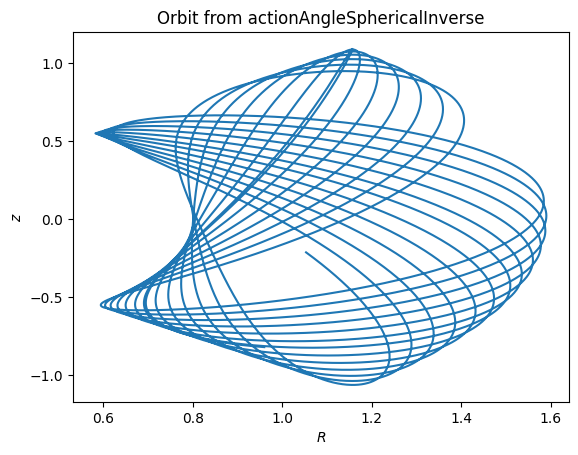

In [5]:
times = numpy.linspace(0.0, 100.0, 10001)
init_angle = numpy.array([1.0, 2.0, 3.0])
angles = numpy.tile(init_angle, (len(times), 1)) + Om[:3] * numpy.tile(times, (3, 1)).T

R, vR, vT, z, vz, phi = aASI(
    jr_val, jphi_val, jz_val, angles[:, 0], angles[:, 1], angles[:, 2]
)

plt.plot(R, z)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Orbit from actionAngleSphericalInverse")

### Comparison with direct orbit integration

Maximum distance between the torus and the integrated orbit: 7.8e-05


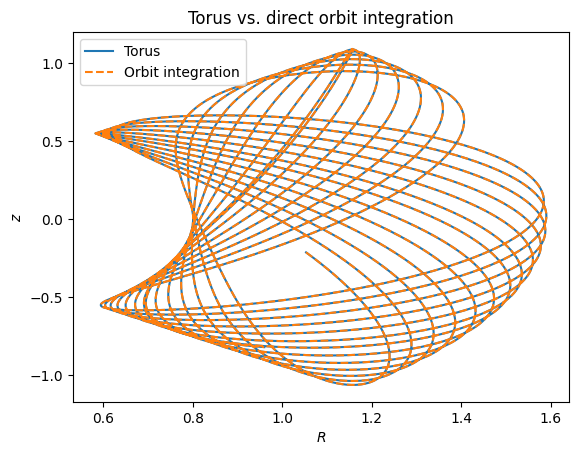

In [6]:
orb = Orbit([R[0], vR[0], vT[0], z[0], vz[0], phi[0]])
orb.integrate(times, nfp)

plt.plot(R, z, label="Torus")
plt.plot(orb.R(times), orb.z(times), "--", label="Orbit integration")
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.legend()
plt.title("Torus vs. direct orbit integration")
sep = numpy.sqrt(
    (R * numpy.cos(phi) - orb.x(times)) ** 2
    + (R * numpy.sin(phi) - orb.y(times)) ** 2
    + (z - orb.z(times)) ** 2
)
print(
    f"Maximum distance between the torus and the integrated orbit: {numpy.amax(sep):.1e}"
)

The two orbits are the same to the accuracy with which the family
interpolates between its grid tori (the maximum distance printed above);
for a torus of the grid itself, the agreement is limited by the orbit
integrator instead.

## The xvFreqs method

`xvFreqs` returns the phase-space coordinates and the frequencies at once:

In [7]:
angler = numpy.linspace(0.0, 2.0 * numpy.pi, 101)
anglephi = numpy.zeros(101)
anglez = numpy.zeros(101)

R, vR, vT, z, vz, phi, OR, Op, Oz = aASI.xvFreqs(
    jr_val, jphi_val, jz_val, angler, anglephi, anglez
)

print(f"Omega_r = {OR:.6f}, Omega_phi = {Op:.6f}, Omega_z = {Oz:.6f}")

Omega_r = 1.261409, Omega_phi = 0.832921, Omega_z = 0.832921


## Orbital torus cross-section

By varying one angle while holding the others fixed, we can visualize a
cross-section of the orbital torus:

Text(0.5, 1.0, 'Torus cross-section (varying $\\theta_r$, $\\theta_\\phi = \\theta_z = 0$)')

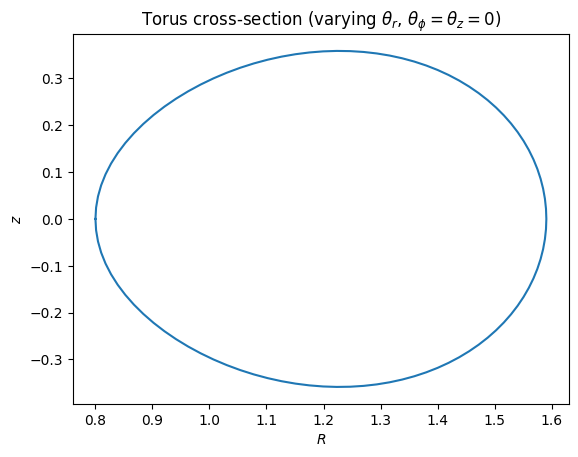

In [8]:
plt.plot(R, z)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title(r"Torus cross-section (varying $\theta_r$, $\theta_\phi = \theta_z = 0$)")

## Mapping a full torus

Sampling the three angles uniformly in $[0, 2\pi]$ maps the entire orbital
torus and shows directly where the orbit spends most of its time:

Text(0.5, 1.0, 'Full orbital torus')

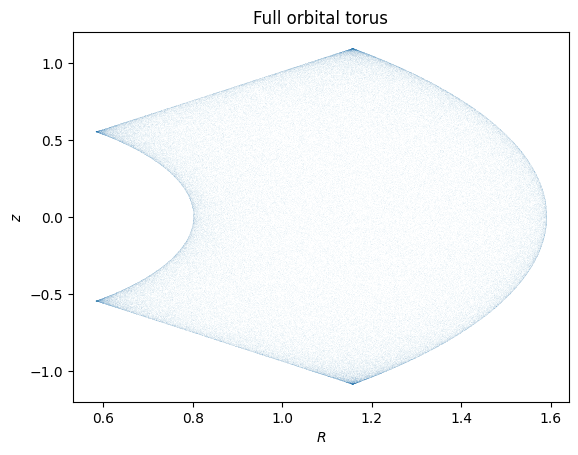

In [9]:
numpy.random.seed(1)
nangles = 200001
angler_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
anglep_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi
anglez_rand = numpy.random.uniform(size=nangles) * 2.0 * numpy.pi

R_torus, _, _, z_torus, _, _ = aASI(
    jr_val, jphi_val, jz_val, angler_rand, anglep_rand, anglez_rand
)

plt.plot(R_torus, z_torus, ",", alpha=0.02)
plt.xlabel(r"$R$")
plt.ylabel(r"$z$")
plt.title("Full orbital torus")

## Tori at different radial actions

In a spherical potential the radial motion is a one-dimensional
libration in $r$, and the tori at a given angular momentum form nested
loops in the $(r, v_r)$ plane, like the one-dimensional tori of
[actionAngleVerticalInverse](vertical_and_inverse.ipynb). The circular
orbit, $J_r = 0$, is the point at the center:

Text(0.5, 1.0, 'Tori at $L = J_z + |J_\\phi| = 1.1$')

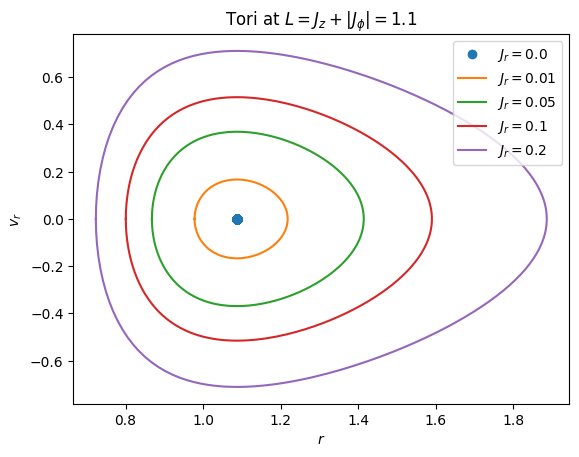

In [10]:
angler = numpy.linspace(0.0, 2.0 * numpy.pi, 201)
for jr in [0.0, 0.01, 0.05, 0.1, 0.2]:
    R, vR, vT, z, vz, phi = aASI(jr, jphi_val, jz_val, angler, 0.0, 0.0)
    r = numpy.sqrt(R**2 + z**2)
    vr = (R * vR + z * vz) / r
    plt.plot(r, vr, "o" if jr == 0.0 else "-", label=rf"$J_r = {jr}$")
plt.xlabel(r"$r$")
plt.ylabel(r"$v_r$")
plt.legend()
plt.title(rf"Tori at $L = J_z + |J_\phi| = {jz_val + abs(jphi_val)}$")

## Specifying a torus by its energy

A torus can also be specified by its energy and total angular momentum
$L = J_z + |J_\phi|$, using the `Jr` method to obtain its radial action:

In [11]:
from galpy.potential import evaluatePotentials

E_val, L_val = (
    evaluatePotentials(nfp, 3.0, 0.0),
    1.1,
)  # an energy inside the grid's range
jr_E = aASI.Jr(E_val, L_val)
print(f"J_r = {jr_E:.6f} for E = {E_val:.4f}, L = {L_val}")
R, vR, vT, z, vz, phi = aASI(jr_E, 0.8 * L_val, 0.2 * L_val, angler, 0.0, 0.0)
E_check = 0.5 * (vR**2 + vT**2 + vz**2) + evaluatePotentials(nfp, R, z)
print(f"Energy along the torus: {numpy.mean(E_check):.6f} +/- {numpy.std(E_check):.1e}")

J_r = 0.551653 for E = -2.3925, L = 1.1
Energy along the torus: -2.392466 +/- 1.2e-08


## Checking against the forward transformation

The forward transformation `actionAngleSpherical` computes actions,
frequencies, and angles from phase-space coordinates by direct quadrature,
independently of the inverse. Sending the points of a torus through it
recovers the actions and angles they were computed from. For the torus
used above, which lies between the tori of the grid, the recovered actions
and angles differ by the family's interpolation error; a torus that is set
up on its own, with `setup_interp=False` and its energy and angular
momentum given in `Es` and `Ls`, is reproduced to the accuracy of the
forward transformation itself:

In [12]:
from galpy.actionAngle import actionAngleSpherical

aAS = actionAngleSpherical(pot=nfp)


def roundtrip(aASI, jr, jphi, jz):
    angler = numpy.linspace(0.0, 2.0 * numpy.pi, 51)
    anglephi, anglez = 0.3 + 1.7 * angler, 0.7 + 2.3 * angler
    out = aASI(jr, jphi, jz, angler, anglephi, anglez)
    jr_f, jphi_f, jz_f, _, _, _, ar_f, ap_f, az_f = aAS.actionsFreqsAngles(*out)
    wrap = lambda d: (d + numpy.pi) % (2.0 * numpy.pi) - numpy.pi
    return (
        numpy.amax(numpy.fabs(jr_f - jr)) / jr,
        max(
            numpy.amax(numpy.fabs(wrap(ar_f - angler))),
            numpy.amax(numpy.fabs(wrap(ap_f - anglephi))),
            numpy.amax(numpy.fabs(wrap(az_f - anglez))),
        ),
    )


dJ, dth = roundtrip(aASI, jr_val, jphi_val, jz_val)
print(
    f"Interpolated family: relative error in J_r = {dJ:.1e}, error in the angles = {dth:.1e}"
)

aASI_single = actionAngleSphericalInverse(pot=nfp, Es=[E_val], Ls=[L_val], mm_npt=48)
dJ, dth = roundtrip(aASI_single, aASI_single.Jr(E_val, L_val), 0.8 * L_val, 0.2 * L_val)
print(
    f"Single torus: relative error in J_r = {dJ:.1e}, error in the angles = {dth:.1e}"
)

Interpolated family: relative error in J_r = 2.9e-08, error in the angles = 2.9e-07


Single torus: relative error in J_r = 8.6e-13, error in the angles = 3.6e-09


Like the other action-angle classes, `actionAngleSphericalInverse` accepts
and returns physical units when set up with `ro=` and `vo=`. See the
action-angle API documentation for details.